In [33]:
library(tidyverse)
#library(psych) # For correlations
library(ggplot2)
library(readr)
library(readxl)
library(reshape2)
library(caret)
library(dplyr)

In [2]:
load("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input.RData")

In [31]:
load("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_no_genotype.RData")

In [34]:
rm(list = ls())

In [35]:
load_and_process <- function(file_path) {
  data <- read.csv(file_path)                  # Load the data
  rownames(data) <- data[[1]]                  # Set the first column as row names
  data <- data[, -1, drop = FALSE]             # Remove the first column
  return(data)
}

In [36]:
cytokine <-  load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/cytokine_variance_input.csv")  
olink  <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/olink_variance_input.csv") 
metabolite  <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/metabolite_variance_input.csv") 
hormone  <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/hormone_variance_input.csv")
platelet <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/platelet_variance_input_removed.csv") #removed missing value >50%
immunoglobulin <- load_and_process ("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/immunoglobulin_variance_input.csv")
cellcounts = read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_inverse_rank_normalized_cellcounts.txt", header = TRUE, stringsAsFactors = FALSE)   ##less raw data
microbiome <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/microbiome_variance_input.csv") 
methylation <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/Mvalue_pca_scores1.csv") #pca scores
colnames(methylation) <- paste0("m", colnames(methylation))
genotype <- load_and_process("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_input/genotype_pca_scores.csv") #pca scores
basicPhenos = load_and_process("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
rownames(basicPhenos)<- basicPhenos[,1]
basicPhenos <- basicPhenos[,-1]
head(basicPhenos)

,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


In [37]:
clean_predictors <- function(data) {
  # Convert to data frame if needed
  data <- as.data.frame(data)
  
  # Ensure unique column names
  names(data) <- make.names(names(data), unique = TRUE)
  
  # Retain only numeric columns
  numeric_data <- data[, sapply(data, is.numeric), drop = FALSE]
  
  # Check if numeric_data is empty
  if (ncol(numeric_data) == 0) {
    message("No numeric columns available in dataset.")
    return(data.frame())  # Return empty data frame
  }
  
  # Remove columns with all NA values
  numeric_data <- numeric_data[, colSums(!is.na(numeric_data)) > 0, drop = FALSE]
  if (ncol(numeric_data) == 0) {
    message("All columns have NA values.")
    return(data.frame())
  }
  
  # Remove constant columns
  non_constant_data <- numeric_data[, apply(numeric_data, 2, function(x) var(x, na.rm = TRUE) > 0), drop = FALSE]
  if (ncol(non_constant_data) == 0) {
    message("No non-constant numeric columns remain in dataset.")
    return(data.frame())
  }
  
  return(non_constant_data)
}

In [38]:
select_significant_features <- function(response, predictors, p_threshold = 0.05) {
  predictors <- clean_predictors(predictors)
  significant_features <- list()
  
  for (col in colnames(predictors)) {
    test <- tryCatch({
      cor.test(response, predictors[[col]], method = "spearman")
    }, error = function(e) NULL)
    
    if (!is.null(test) && !is.na(test$p.value) && test$p.value < p_threshold) {
      significant_features[[col]] <- predictors[[col]]
    }
  }
  
  if (length(significant_features) > 0) {
    return(as.data.frame(significant_features))
  } else {
    return(data.frame())
  }
}

In [39]:
remove_collinear_features <- function(predictors, threshold = 0.4) {
  if (!is.data.frame(predictors)) {
    predictors <- as.data.frame(predictors)
  }
  
  predictors <- predictors %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(where(~ var(., na.rm = TRUE) > 0))
  
  if (ncol(predictors) < 2) {
    return(predictors)
  }
  
  cor_matrix <- cor(
    predictors,
    method = "spearman",
    use = "pairwise.complete.obs"
  )
  
  if (nrow(cor_matrix) != ncol(cor_matrix)) {
    stop("Correlation matrix dimensions mismatch. Check predictors.")
  }
  
  to_remove <- c()
  for (i in 1:(ncol(cor_matrix) - 1)) {
    for (j in (i + 1):ncol(cor_matrix)) {
      if (abs(cor_matrix[i, j]) > threshold) {
        var_i <- var(predictors[[i]], na.rm = TRUE)
        var_j <- var(predictors[[j]], na.rm = TRUE)
        
        if (var_i < var_j) {
          to_remove <- c(to_remove, colnames(predictors)[i])
        } else {
          to_remove <- c(to_remove, colnames(predictors)[j])
        }
      }
    }
  }
  
  predictors <- predictors[, !colnames(predictors) %in% unique(to_remove), drop = FALSE]
  return(predictors)
}

In [40]:
# calculate_adjusted_r2 <- function(response, predictors) {
#   # Check for duplicate column names
#   if (any(duplicated(names(predictors)))) {
#     stop("Duplicate column names found in predictors.")
#   }
  
#   # Fit the model if no duplicates
#   if (ncol(predictors) > 0) {
#     model <- lm(response ~ ., data = predictors)
#     adj_r2 <- summary(model)$adj.r.squared
#     return(max(0, adj_r2))
#   } else {
#     return(NA)
#   }
# }

In [42]:
calculate_adjusted_r2 <- function(response, predictors = NULL, sex_df = NULL) {
  if (is.null(predictors)) {
    predictors <- data.frame(row.names = seq_along(response))
  }
  if (!is.data.frame(predictors)) predictors <- as.data.frame(predictors)

  model_df <- data.frame(response = response)
  if (!is.null(sex_df)) model_df <- cbind(model_df, sex_df)
  if (ncol(predictors) > 0) model_df <- cbind(model_df, predictors)

  model_df <- model_df[complete.cases(model_df), , drop = FALSE]
  colnames(model_df) <- make.names(colnames(model_df), unique = TRUE)

  if (ncol(model_df) <= 1) return(NA_real_)

  model <- lm(response ~ ., data = model_df)
  max(0, summary(model)$adj.r.squared)
}

In [43]:
###add gender as first catogray
# Plot vertical ##change order from biggest to the smallest
# Combine all datasets into a list
all_data <- list(
  #"Genotype" = genotype,
  "methylation" = methylation,
  "Proteomics" = olink,
  "Cytokine" = cytokine,
  "Metabolites" = metabolite,
  "Cell_count" = cellcounts,
  "Hormones" = hormone,
  "Immunoglobulin" = immunoglobulin,
  "Microbiome" = microbiome,
  "Platelets" = platelet
)
for (level in names(all_data)) {
  print(paste("Ensuring unique column names for:", level))
  colnames(all_data[[level]]) <- make.unique(make.names(colnames(all_data[[level]])))
}
# Keep only samples with IDs starting with HV
filter_hv <- function(data) data[grep("^HV", rownames(data)), , drop = FALSE]
all_data <- lapply(all_data, filter_hv)
# Intersect sample IDs across all layers and phenotype table
common_samples <- Reduce(intersect, lapply(all_data, rownames))
common_samples <- intersect(common_samples, rownames(basicPhenos))
all_data <- lapply(all_data, function(x) x[common_samples, , drop = FALSE])
basic <- basicPhenos[common_samples, , drop = FALSE]
# Clean Gender and keep complete Age/Gender samples
basic$Gender <- trimws(as.character(basic$Gender))
basic$Gender[basic$Gender == ""] <- NA
basic$Gender <- factor(basic$Gender)
keep <- complete.cases(basic[, c("Age", "Gender")])
basic <- basic[keep, , drop = FALSE]
all_data <- lapply(all_data, function(x) x[rownames(basic), , drop = FALSE])
cat("Number of common samples after Age/Gender filtering:", nrow(basic), "\n")
results <- data.frame()
response <- basic$Age
sex_df <- data.frame(Gender = basic$Gender)
head(response)
# Helper: calculate adjusted R2 with optional sex covariate
calculate_adjusted_r2 <- function(response, predictors = NULL, sex_df = NULL) {
  if (is.null(predictors)) {
    predictors <- data.frame(row.names = seq_along(response))
  }
  if (!is.data.frame(predictors)) predictors <- as.data.frame(predictors)
  model_df <- data.frame(response = response)
  if (!is.null(sex_df)) model_df <- cbind(model_df, sex_df)
  if (ncol(predictors) > 0) model_df <- cbind(model_df, predictors)
  model_df <- model_df[complete.cases(model_df), , drop = FALSE]
  colnames(model_df) <- make.names(colnames(model_df), unique = TRUE)
  # Need at least one predictor column
  if (ncol(model_df) <= 1) return(NA_real_)
  model <- lm(response ~ ., data = model_df)
  max(0, summary(model)$adj.r.squared)
}
# Baseline model: Gender only (Category 1)
cumulative_r2 <- calculate_adjusted_r2(response, predictors = NULL, sex_df = sex_df)
temp_results <- data.frame(
  Data_Level = "Gender",
  Adjusted_R2 = cumulative_r2,
  Incremental_R2 = cumulative_r2
)
# Start with empty omics predictors; Gender is already in sex_df
predictors_so_far <- data.frame(row.names = rownames(basic))
# Iterate through omics layers (Category 2+)
for (level in names(all_data)) {
  print(paste("Processing Data Level:", level))
  if (nrow(all_data[[level]]) == 0 || ncol(all_data[[level]]) == 0) {
    print(paste("Dataset for", level, "is empty. Skipping."))
    next
  }
  predictors <- clean_predictors(all_data[[level]])
  # Check whether predictors are valid
  cat("Number of predictors after cleaning:", ncol(predictors), "\n")
  if (ncol(predictors) == 0) {
    print(paste("No valid predictors for:", level))
    next
  }
  # Feature selection by Spearman correlation with Age
  predictors <- select_significant_features(response, predictors, p_threshold = 0.05)
  if (ncol(predictors) == 0) {
    print(paste("No significant features for:", level))
    next
  }
  # Remove collinear features within this layer
  predictors <- remove_collinear_features(predictors, threshold = 0.4)
  if (ncol(predictors) == 0) {
    print(paste("All features removed due to collinearity for:", level))
    next
  }
  combined_predictors <- cbind(predictors_so_far, predictors)
  colnames(combined_predictors) <- make.unique(colnames(combined_predictors))
  # Check combined predictor matrix
  cat("Combined predictors dimensions:", dim(combined_predictors), "\n")
  if (ncol(combined_predictors) == 0) {
    print("Combined predictors are empty. Skipping this level.")
    next
  }
  # Calculate adjusted R2 with Gender always included
  adj_r2 <- calculate_adjusted_r2(response, combined_predictors, sex_df = sex_df)
  incremental_r2 <- max(0, adj_r2 - cumulative_r2)
  cumulative_r2 <- adj_r2
  # Store layer result
  temp_results <- rbind(temp_results, data.frame(
    Data_Level = level,
    Adjusted_R2 = cumulative_r2,
    Incremental_R2 = incremental_r2
  ))
  predictors_so_far <- combined_predictors
}
results <- rbind(results, temp_results)
print(results)

[1] "Ensuring unique column names for: methylation"
[1] "Ensuring unique column names for: Proteomics"
[1] "Ensuring unique column names for: Cytokine"
[1] "Ensuring unique column names for: Metabolites"
[1] "Ensuring unique column names for: Cell_count"
[1] "Ensuring unique column names for: Hormones"
[1] "Ensuring unique column names for: Immunoglobulin"
[1] "Ensuring unique column names for: Microbiome"
[1] "Ensuring unique column names for: Platelets"
Number of common samples after Age/Gender filtering: 185 


[1] 20 29 24 25 21 21

[1] "Processing Data Level: methylation"
Number of predictors after cleaning: 306 


Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute e

Combined predictors dimensions: 185 21 
[1] "Processing Data Level: Proteomics"
Number of predictors after cleaning: 70 


...

Combined predictors dimensions: 185 70 
[1] "Processing Data Level: Microbiome"
Number of predictors after cleaning: 524 


Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute e

Combined predictors dimensions: 185 90 
[1] "Processing Data Level: Platelets"
Number of predictors after cleaning: 11 


Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(response, predictors[[col]], method = "spearman"):
“Cannot compute e

[1] "No significant features for: Platelets"
      Data_Level Adjusted_R2 Incremental_R2
1         Gender 0.007121042    0.007121042
2    methylation 0.759974430    0.752853388
3     Proteomics 0.785190924    0.025216494
4       Cytokine 0.791627579    0.006436655
5    Metabolites 0.822248196    0.030620616
6     Cell_count 0.825631545    0.003383350
7       Hormones 0.830878304    0.005246759
8 Immunoglobulin 0.829214043    0.000000000
9     Microbiome 0.811008460    0.000000000


                    Data_Level Adjusted_R2 Incremental_R2          Age
1                          Sex 0.007121042    0.007121042 Age Category
2              DNA methylation 0.759974430    0.752853388 Age Category
3                   Proteomics 0.785190924    0.025216494 Age Category
4            Cytokine response 0.791627579    0.006436655 Age Category
5                 Metabolomics 0.822248196    0.030620616 Age Category
6           Immune cell counts 0.825631545    0.003383350 Age Category
7 Circulating endocrine traits 0.830878304    0.005246759 Age Category
8    Circulating immune traits 0.829214043    0.000000000 Age Category
9                  Microbiomes 0.811008460    0.000000000 Age Category


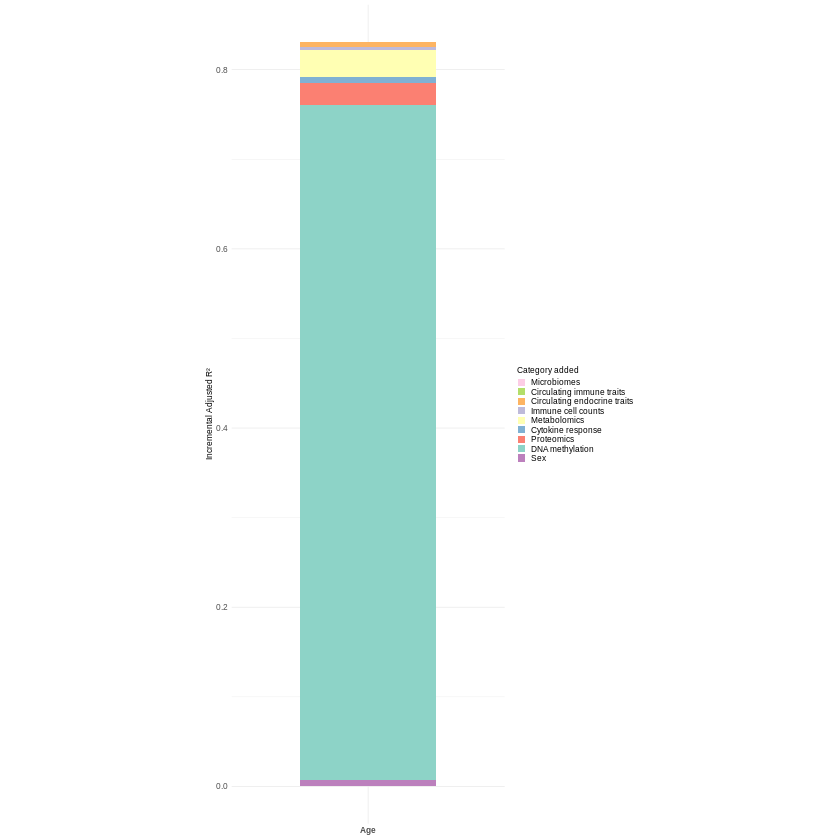

In [58]:
# Plot vertical ##change order from biggest to the smallest

# Keep Age label
results$Age <- "Age Category"

# Keep Data_Level order as current appearance
results$Data_Level <- factor(results$Data_Level, levels = unique(results$Data_Level))

# Rename levels to match the figure labels
results$Data_Level <- as.character(results$Data_Level)
results$Data_Level[results$Data_Level == "Gender"]         <- "Sex"
results$Data_Level[results$Data_Level == "methylation"]    <- "DNA methylation"
results$Data_Level[results$Data_Level == "Proteomics"]     <- "Proteomics"
results$Data_Level[results$Data_Level == "Metabolites"]    <- "Metabolomics"
results$Data_Level[results$Data_Level == "Cytokine"]       <- "Cytokine response"
results$Data_Level[results$Data_Level == "Cell_count"]     <- "Immune cell counts"
results$Data_Level[results$Data_Level == "Microbiome"]     <- "Microbiomes"
results$Data_Level[results$Data_Level == "Hormones"]       <- "Circulating endocrine traits"
results$Data_Level[results$Data_Level == "Immunoglobulin"] <- "Circulating immune traits"
results$Data_Level <- factor(results$Data_Level, levels = unique(results$Data_Level))

print(results)

# Custom palette:
# Gender color + your 8 provided colors in order
color_palette <- c(
  "Sex" = "#BC80BD",
  "DNA methylation" = "#8DD3C7",
  "Proteomics" = "#FB8072",
  "Metabolomics" = "#FFFFB3",
  "Cytokine response" = "#80B1D3",
  "Immune cell counts" = "#BEBADA",
  "Microbiomes" = "#FCCDE5",
  "Circulating endocrine traits" = "#FDB462",
  "Circulating immune traits" = "#B3DE69"
)

# Keep only categories that exist in current results
color_palette <- color_palette[levels(results$Data_Level)]

# Reverse Data Level order for plotting display
results$Data_Level <- factor(results$Data_Level, levels = rev(levels(results$Data_Level)))
color_palette <- color_palette[levels(results$Data_Level)]

# Plot with vertical bars
p <- ggplot(results, aes(x = Age, y = Incremental_R2, fill = Data_Level)) +
  geom_bar(stat = "identity", position = position_stack(reverse = FALSE), width = 0.6) +
  scale_fill_manual(values = color_palette) +
  scale_x_discrete(labels = c("Age Category" = "Age")) +
  theme_minimal(base_size = 5) +
  theme(
    plot.margin = unit(c(1, 1, 1, 1), "mm"),
    axis.text.x = element_text(size = 5, face = "bold"),
    axis.text.y = element_text(size = 5),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 5),
    axis.ticks.x = element_blank(),
    legend.title = element_text(size = 5),
    legend.text = element_text(size = 5),
    plot.title = element_text(size = 5),
      legend.key.size = unit(2, "mm"),
  legend.key.height = unit(2, "mm"),
  legend.key.width = unit(2, "mm"),
    aspect.ratio = 3
  ) +
  labs(
    title = NULL,
    y = "Incremental Adjusted R²",
    fill = "Category added"
  )
# Save as PDF/PNG with requested size
fig_w_mm <- 70
fig_h_mm <- 88 * 7 / 10
ggsave(
  "/vol/projects/yzhang/500FG_aging/output/11_explained_variance/cumulative_variance_gender_nature.pdf",
  plot = p, width = fig_w_mm, height = fig_h_mm, units = "mm"
)
print(p)


In [59]:
save.image("/vol/projects/yzhang/500FG_aging/input/variance/cumulative_variance_gender.RData")

In [ ]:
load()